In [1]:
print("hello colab")

hello colab


In [4]:
import sklearn
print(sklearn.__version__)

1.6.1


In [5]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target

print("ขนาดข้อมูล", X.shape)
print("สิ่งที่วัด", iris.feature_names)
print("สายพันธุ์", iris.target_names)
print("จำนวนต่อสายพันธุ์", np.bincount(y))
print("ค่าต่ำสุดแต่ละคอลัมน์", X.min(axis=0))
print("ค่าสูงสุดแต่ละคอลัมน์", X.max(axis=0))

ขนาดข้อมูล (150, 4)
สิ่งที่วัด ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
สายพันธุ์ ['setosa' 'versicolor' 'virginica']
จำนวนต่อสายพันธุ์ [50 50 50]
ค่าต่ำสุดแต่ละคอลัมน์ [4.3 2.  1.  0.1]
ค่าสูงสุดแต่ละคอลัมน์ [7.9 4.4 6.9 2.5]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("กองฝึก", len(X_train), "ดอก")
print("กองสอบ", len(X_test), "ดอก")
print("เฉลยในกองฝึก", np.bincount(y_train))
print("เฉลยในกองสอบ", np.bincount(y_test))

กองฝึก 105 ดอก
กองสอบ 45 ดอก
เฉลยในกองฝึก [31 37 37]
เฉลยในกองสอบ [19 13 13]


In [7]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

print("คำตอบ 5 ข้อแรกของนักเรียนหลับตาเดา", baseline.predict(X_test[:5]))
print("คะแนนเดามั่ว", baseline.score(X_test, y_test))

คำตอบ 5 ข้อแรกของนักเรียนหลับตาเดา [1 1 1 1 1]
คะแนนเดามั่ว 0.28888888888888886


In [8]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("คะแนนต้นไม้", model.score(X_test, y_test))

คะแนนต้นไม้ 1.0


In [9]:
from sklearn.tree import export_text

print(export_text(model, feature_names=iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |   |--- class: 1
|   |   |   |--- petal 

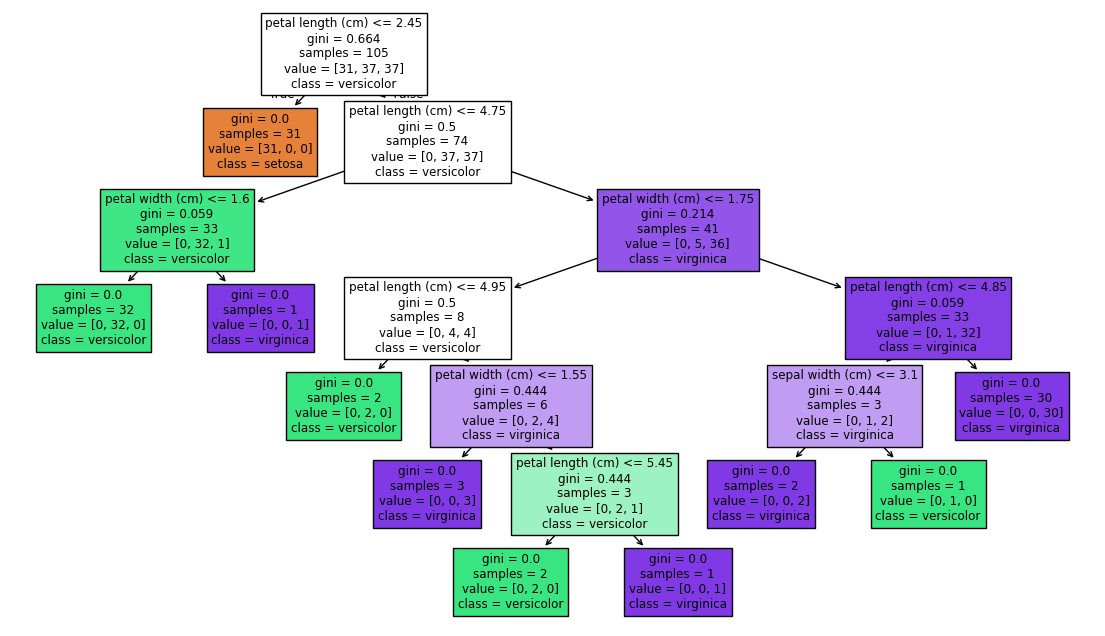

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()

In [10]:
new_flowers = np.array([
    [5.0, 3.4, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.5, 3.0, 5.8, 2.2],
])

pred = model.predict(new_flowers)
print("คำตอบ", pred)
print("ชื่อสายพันธุ์", [iris.target_names[p] for p in pred])

คำตอบ [0 1 2]
ชื่อสายพันธุ์ [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [11]:
print("คะแนนเมื่อสอบด้วยกองฝึก", model.score(X_train, y_train))
print("คะแนนเมื่อสอบด้วยกองสอบ", model.score(X_test, y_test))

คะแนนเมื่อสอบด้วยกองฝึก 1.0
คะแนนเมื่อสอบด้วยกองสอบ 1.0


In [12]:
from sklearn.datasets import load_wine

wine = load_wine()
Xw, yw = wine.data, wine.target
print("ขนาดข้อมูลไวน์", Xw.shape, "แต่ละตระกูล", np.bincount(yw))

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.3, random_state=42)

wine_model = DecisionTreeClassifier(random_state=42)
wine_model.fit(Xw_train, yw_train)

print("คะแนนเมื่อสอบด้วยกองฝึก", round(wine_model.score(Xw_train, yw_train), 4))
print("คะแนนเมื่อสอบด้วยกองสอบ", round(wine_model.score(Xw_test, yw_test), 4))

ขนาดข้อมูลไวน์ (178, 13) แต่ละตระกูล [59 71 48]
คะแนนเมื่อสอบด้วยกองฝึก 1.0
คะแนนเมื่อสอบด้วยกองสอบ 0.963


In [13]:
X_leak = np.vstack([Xw_train, Xw_test])
y_leak = np.concatenate([yw_train, yw_test])

leak_model = DecisionTreeClassifier(random_state=42)
leak_model.fit(X_leak, y_leak)

print("คะแนนของโมเดลที่เห็นข้อสอบล่วงหน้า", round(leak_model.score(Xw_test, yw_test), 4))

คะแนนของโมเดลที่เห็นข้อสอบล่วงหน้า 1.0


In [14]:
for rs in [0, 1, 7, 42, 100]:
    a, b, c, d = train_test_split(Xw, yw, test_size=0.3, random_state=rs)
    m = DecisionTreeClassifier(random_state=42).fit(a, c)
    print("random_state", rs, "ได้คะแนน", round(m.score(b, d), 4))

random_state 0 ได้คะแนน 0.9259
random_state 1 ได้คะแนน 0.9074
random_state 7 ได้คะแนน 0.9074
random_state 42 ได้คะแนน 0.963
random_state 100 ได้คะแนน 0.8148


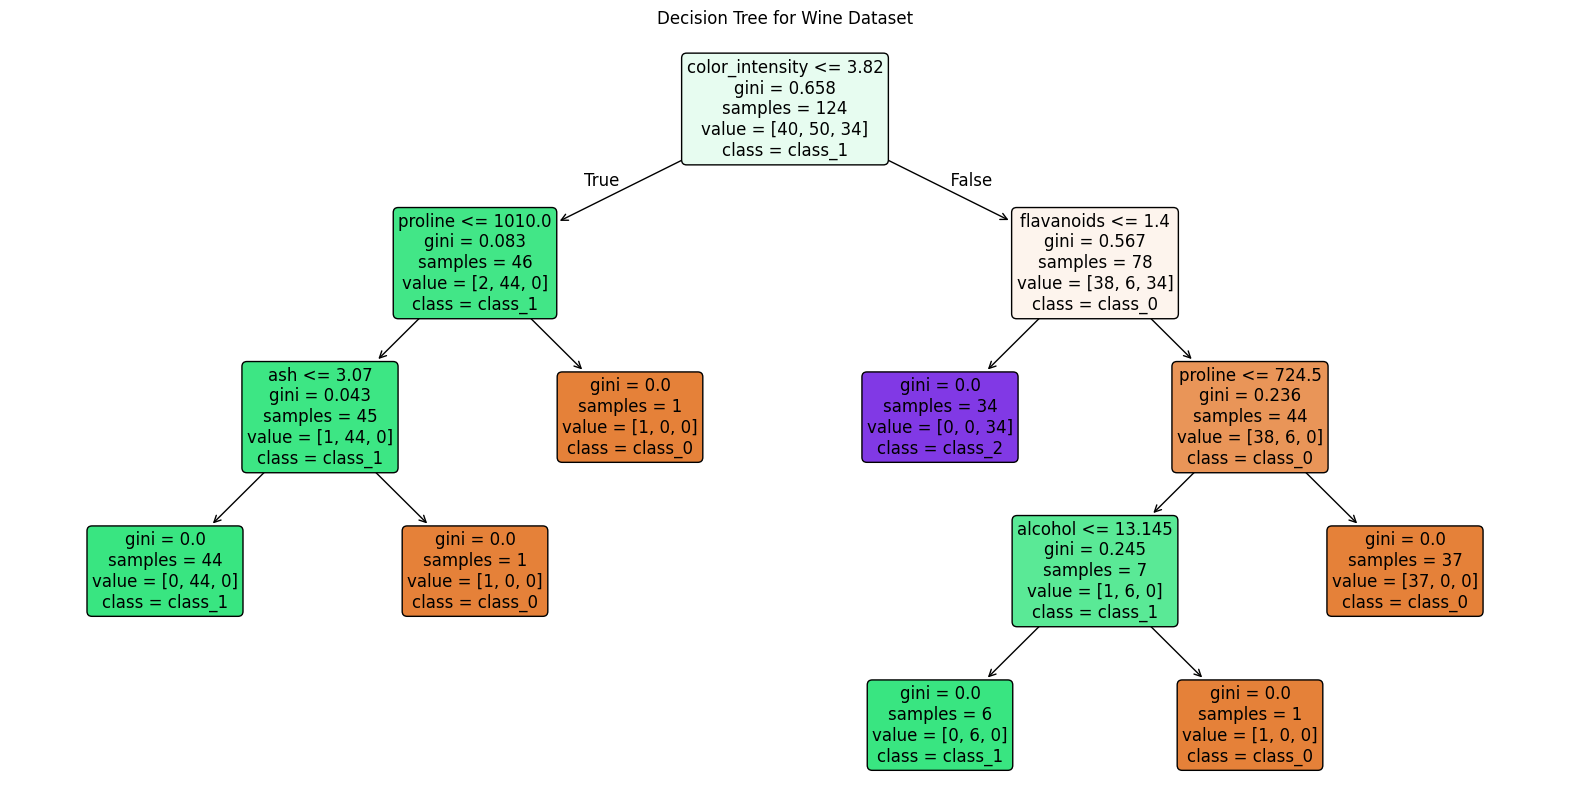


คำถามข้อแรกใช้ค่าเคมีตัวนี้: color_intensity


In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# วาดแผนภูมิของโมเดลไวน์
plt.figure(figsize=(20, 10))
plot_tree(wine_model,
          feature_names=wine.feature_names,
          class_names=wine.target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Decision Tree for Wine Dataset")
plt.show()

# แสดงชื่อฟีเจอร์แรกที่ใช้ในการแยก (Root node)
root_feature_index = wine_model.tree_.feature[0]
root_feature_name = wine.feature_names[root_feature_index]
print(f"\nคำถามข้อแรกใช้ค่าเคมีตัวนี้: {root_feature_name}")